# Diagnóstico Probabilístico: Modelo "Chest Clinic" (Asia)
**Curso:** Modelos Gráficos Probabilísticos  
**Proyecto:** Evaluación Continua 3 (EC3)  
**Descripción:** Implementación de una Red Bayesiana para el diagnóstico de enfermedades pulmonares utilizando la librería `pgmpy`.

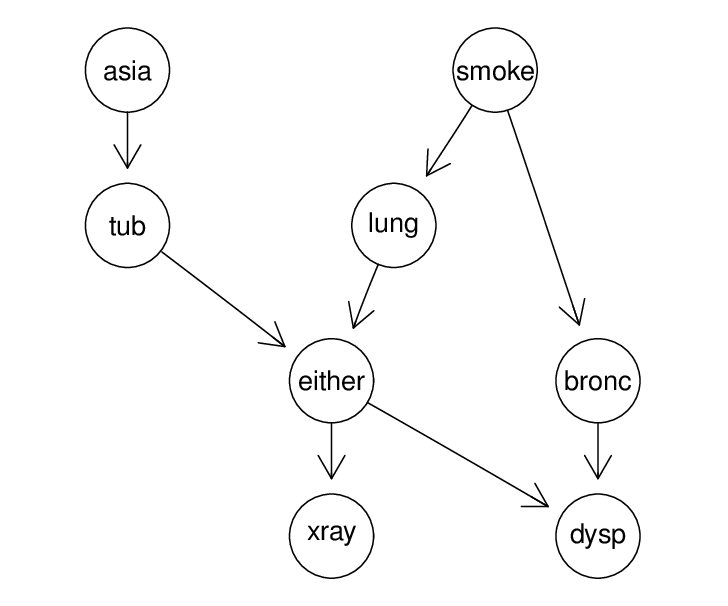

## Instalación de dependencia

In [ ]:
pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 8.9 MB/s eta 0:00:00


##Contrucción del Grafo y CPTs

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# 1. Definición de la estructura de la red
model = DiscreteBayesianNetwork([
    ('A', 'T'), ('S', 'L'), ('S', 'B'),
    ('T', 'E'), ('L', 'E'), ('E', 'X'),
    ('E', 'D'), ('B', 'D')
])

# 2. Configuración de las Tablas de Probabilidad Condicional (CPTs)
# Valores basados en la imagen del modelo Chest Clinic
cpd_a = TabularCPD(variable='A', variable_card=2, values=[[0.99], [0.01]])
cpd_s = TabularCPD(variable='S', variable_card=2, values=[[0.50], [0.50]])

cpd_t = TabularCPD(variable='T', variable_card=2, values=[[0.99, 0.95], [0.01, 0.05]],
                   evidence=['A'], evidence_card=[2])

cpd_l = TabularCPD(variable='L', variable_card=2, values=[[0.99, 0.90], [0.01, 0.10]],
                   evidence=['S'], evidence_card=[2])

cpd_b = TabularCPD(variable='B', variable_card=2, values=[[0.70, 0.20], [0.30, 0.80]],
                   evidence=['S'], evidence_card=[2])

# Nodo Either (E): Probabilidad de Anormalidad dado T o L [cite: 14, 21, 24]
cpd_e = TabularCPD(variable='E', variable_card=2,
                   values=[[1, 0, 0, 0], [0, 1, 1, 1]],
                   evidence=['L', 'T'], evidence_card=[2, 2])

cpd_x = TabularCPD(variable='X', variable_card=2, values=[[0.95, 0.02], [0.05, 0.98]],
                   evidence=['E'], evidence_card=[2])

cpd_d = TabularCPD(variable='D', variable_card=2,
                   values=[[0.9, 0.2, 0.3, 0.1], [0.1, 0.8, 0.7, 0.9]],
                   evidence=['E', 'B'], evidence_card=[2, 2])

# Añadir CPTs y validar el modelo
model.add_cpds(cpd_a, cpd_s, cpd_t, cpd_l, cpd_b, cpd_e, cpd_x, cpd_d)
print(f"¿El modelo es válido?: {model.check_model()}")

infer = VariableElimination(model)

¿El modelo es válido?: True


##Identificación de Independencias Locales

In [ ]:
print("\n--- INDEPENDENCIAS LOCALES POR VARIABLE ---")
for node in model.nodes():
    print(f"{node}: {model.local_independencies(node)}")


--- INDEPENDENCIAS LOCALES POR VARIABLE ---
A: (A ⟂ S, L, B)
T: (T ⟂ S, L, B | A)
S: (S ⟂ A, T)
L: (L ⟂ A, B, T | S)
B: (B ⟂ T, A, E, X, L | S)
E: (E ⟂ A, S, B | L, T)
X: (X ⟂ T, A, S, L, B, D | E)
D: (D ⟂ T, A, S, L, X | E, B)


##Resolución de consultas probabilísticas

In [ ]:
print("\n--- RESPUESTAS A LAS PREGUNTAS ---")

# Pregunta A: Probabilidad de T, L o B dado Disnea (D=1) y Rayos X anormal (X=1) [cite: 29]
res_a_t = infer.query(variables=['T'], evidence={'D': 1, 'X': 1})
res_a_l = infer.query(variables=['L'], evidence={'D': 1, 'X': 1})
res_a_b = infer.query(variables=['B'], evidence={'D': 1, 'X': 1})
print(f"A) Probabilidad con Disnea y RayosX anormales:")
print(f"   - Tuberculosis: {res_a_t.values[1]*100:.2f}%")
print(f"   - Cáncer de Pulmón: {res_a_l.values[1]*100:.2f}%")
print(f"   - Bronquitis: {res_a_b.values[1]*100:.2f}%")

# Pregunta B: Asia (A=1) y Rayos X anormal (X=1). ¿Tuberculosis? [cite: 30, 31]
res_b = infer.query(variables=['T'], evidence={'A': 1, 'X': 1})
print(f"B) Probabilidad de Tuberculosis (Viajó a Asia + RayosX anormal): {res_b.values[1]*100:.2f}%")

# Pregunta C: Fumador (S=1) y Disnea (D=1). ¿Bronquitis o Cáncer? [cite: 32, 33]
res_c_b = infer.query(variables=['B'], evidence={'S': 1, 'D': 1})
res_c_l = infer.query(variables=['L'], evidence={'S': 1, 'D': 1})
print(f"C) Si es fumador y tiene disnea:")
print(f"   - Probabilidad de Bronquitis: {res_c_b.values[1]*100:.2f}%")
print(f"   - Probabilidad de Cáncer de Pulmón: {res_c_l.values[1]*100:.2f}%")

# Pregunta D: Radiografía anormal (X=1). ¿TBC o Cáncer? [cite: 34]
# (Representado por la variable intermedia 'E' que es 'Either T or L')
res_d = infer.query(variables=['E'], evidence={'X': 1})
print(f"D) Probabilidad de tener Tuberculosis O Cáncer dado RayosX anormales: {res_d.values[1]*100:.2f}%")

# Pregunta E: Fumador (S=1), Disnea (D=1) y Rayos X anormal (X=1). ¿Cáncer? [cite: 35, 36]
res_e = infer.query(variables=['L'], evidence={'S': 1, 'D': 1, 'X': 1})
print(f"E) Probabilidad de Cáncer (Fumador + Disnea + RayosX anormal): {res_e.values[1]*100:.2f}%")


--- RESPUESTAS A LAS PREGUNTAS ---
A) Probabilidad con Disnea y RayosX anormales:
   - Tuberculosis: 10.87%
   - Cáncer de Pulmón: 60.40%
   - Bronquitis: 80.86%
B) Probabilidad de Tuberculosis (Viajó a Asia + RayosX anormal): 33.77%
C) Si es fumador y tiene disnea:
   - Probabilidad de Bronquitis: 95.14%
   - Probabilidad de Cáncer de Pulmón: 12.61%
D) Probabilidad de tener Tuberculosis O Cáncer dado RayosX anormales: 57.60%
E) Probabilidad de Cáncer (Fumador + Disnea + RayosX anormal): 69.33%


##Interpretación de resultados:

*   Pregunta A (Diagnóstico General): Ante un cuadro de disnea y rayos X anormales, el paciente tiene una probabilidad de 80.86% de sufrir Bronquitis, siendo esta la causa más probable frente al Cáncer (60.40%) y la Tuberculosis (10.87%).

*   Pregunta B (Factor Geográfico): Un antecedente de viaje a Asia con radiografía anormal sitúa la probabilidad de Tuberculosis en un 33.77%.

*   Pregunta C (Hábito de Fumar): Un fumador con disnea presenta una probabilidad casi total de Bronquitis (95.14%), mientras que el riesgo de Cáncer en este estado inicial de evidencia es del 12.61%.

*   Pregunta D (Evidencia Radiológica): La presencia de una anomalía en los Rayos X indica una probabilidad del 57.60% de que el paciente padezca o bien Tuberculosis o bien Cáncer de Pulmón.

*   Pregunta E (Caso Crítico): En el escenario donde se combina el tabaquismo, la disnea y una placa anormal, la probabilidad de Cáncer de Pulmón escala al 69.33%.